# Baseline

## Logistic Regression

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../data/creditcard.csv")

df["Hour"] = (df["Time"] // 3600) % 24
df["Amount"] = np.log1p(df["Amount"])   

X = df.drop(columns=["Class", "Time"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

accuracy = (model.predict(X_test) == y_test).mean()  
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9992


## Confusion Matrix

In [4]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

[[56851    13]
 [   34    64]]
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8312    0.6531    0.7314        98

    accuracy                         0.9992     56962
   macro avg     0.9153    0.8264    0.8655     56962
weighted avg     0.9991    0.9992    0.9991     56962



## Baseline Findings

A plain Logistic Regression achieves **99.92% accuracy** — which sounds
impressive until compared against the trivial baseline: a model that always
predicts "not fraud" scores 99.83% without looking at a single feature.
The 30-feature model adds just 0.09 percentage points of accuracy.

The fraud-class metrics reveal the real picture:

- **Recall = 0.65** — of the 98 frauds in the test set, 34 slipped through
  undetected (more than 1 in 3). In production, these are stolen cards that
  keep working.
- **Precision = 0.83** — when the model does flag a transaction, it is right
  83% of the time (only 13 false alarms).

The model is *conservative*: trained on 99.83% negative examples, it learned
that "not fraud" is almost always the safe bet, so it only flags cases it is
very sure about. High precision, low recall.

**Conclusion:** accuracy (and the weighted averages it dominates) is the wrong
lens for this problem. From here on, evaluation focuses on the fraud class:
precision, recall, and the precision-recall curve.

## PR vs ROC Curve

Average Precision (PR-AUC): 0.7368
ROC-AUC:                    0.9593


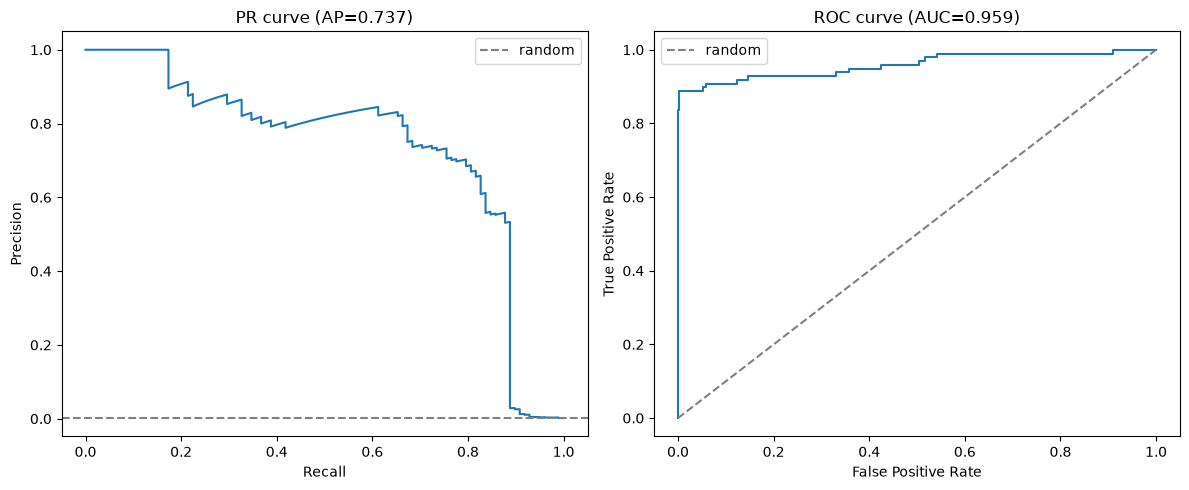

In [5]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test)[:, 1] 

ap = average_precision_score(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)
print(f"Average Precision (PR-AUC): {ap:.4f}")
print(f"ROC-AUC:                    {roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)
axes[0].plot(recall, precision)
axes[0].axhline(y_test.mean(), color="gray", ls="--", label="random")
axes[0].set(xlabel="Recall", ylabel="Precision", title=f"PR curve (AP={ap:.3f})")
axes[0].legend()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
axes[1].plot(fpr, tpr)
axes[1].plot([0, 1], [0, 1], color="gray", ls="--", label="random")
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title=f"ROC curve (AUC={roc_auc:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

## PR vs ROC: why the two numbers disagree

The same model scores **ROC-AUC = 0.959** but only **AP = 0.737**. The
difference comes down to denominators.

The ROC curve cannot meaningfully capture the number of false positives,
because FPR = FP / (all normal transactions), and the normal transactions
(56,864) vastly outnumber any realistic amount of FPs. Even a tenfold
increase in false alarms (13 → 130) only moves the FPR from 0.0002 to 0.002 —
an invisible shift on the ROC axis. Precision, in contrast, compares the FPs
against the model's own positive predictions (TP + FP), a small denominator,
so the same increase drops precision from 0.83 to roughly 0.40. In extreme
imbalance, ROC-AUC is flattering; the PR curve tells the truth.

**The precision cliff.** Up to recall ≈ 0.85, precision stays above 0.5.
Beyond that, it collapses toward zero: the last ~12 frauds receive
probabilities so low — they look almost identical to normal transactions —
that catching them requires lowering the threshold to nearly 0, which flags
thousands of normal transactions along with them (precision ≈ 0.02, about
50 false alarms per real fraud). Perfect recall is therefore not a realistic
target; for this model, the practical ceiling sits around recall 0.85–0.88.